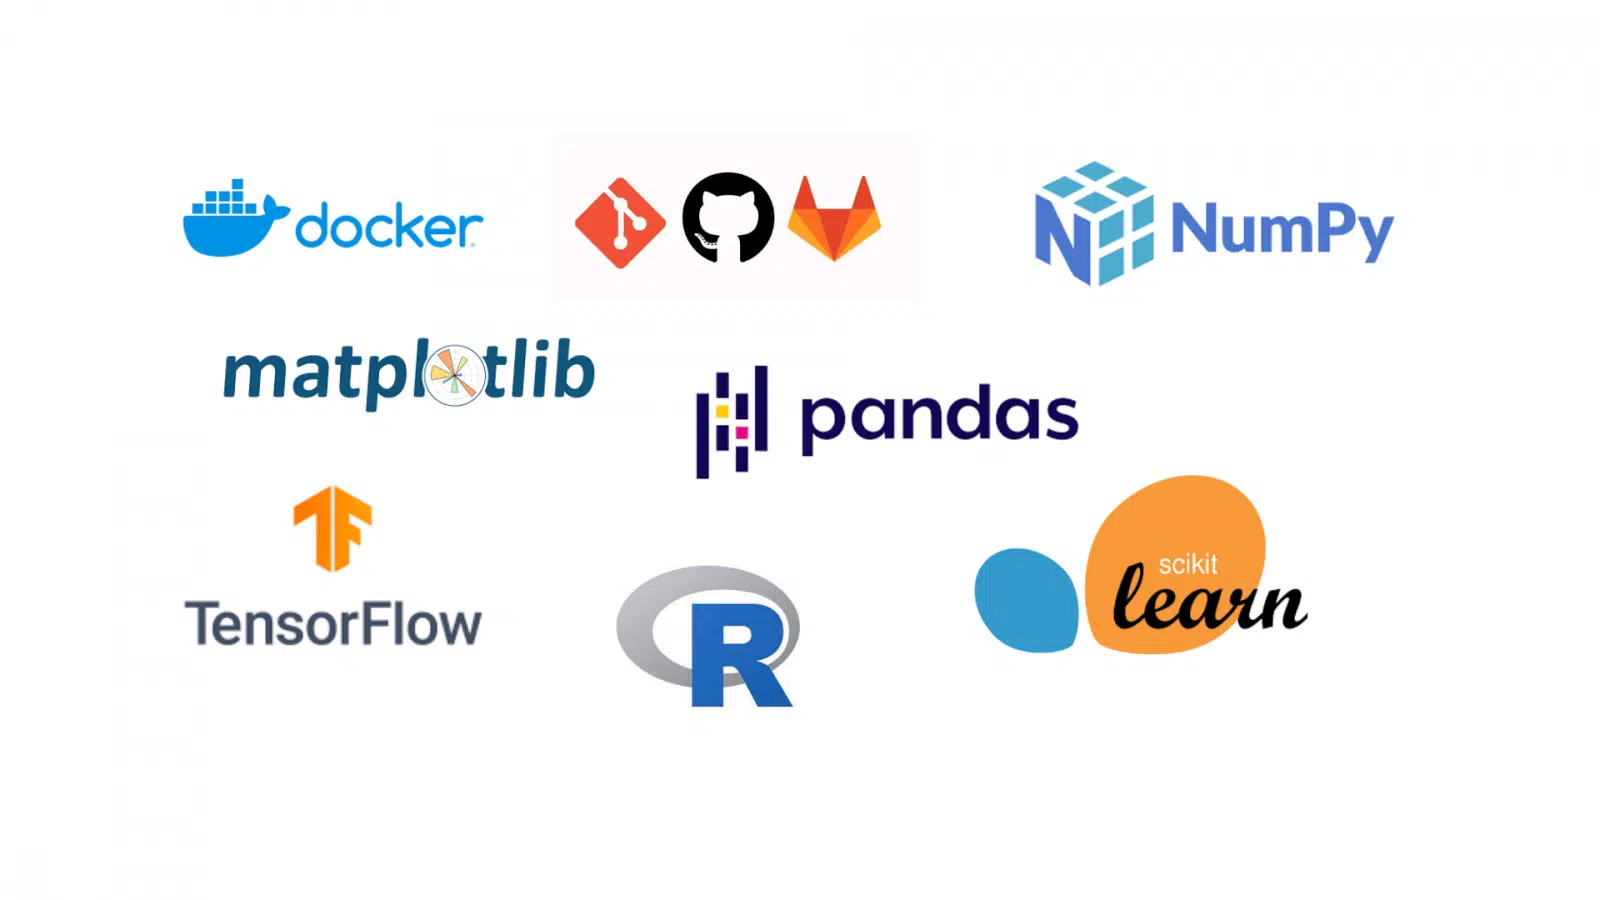

In [1]:
import requests
from PIL import Image
from io import BytesIO

# 1. Votre adresse URL
url = 'https://larevueia.fr/wp-content/uploads/2021/10/outils_ML.png.webp'

# 2. On va chercher l'image sur internet (le "téléchargement" invisible)
reponse = requests.get(url)

# 3. On transforme le résultat en image lisible par PIL
img = Image.open(BytesIO(reponse.content))

# 4. On affiche
display(img)

#  L'AKRAM-PENDIUM DE LA DATA SCIENCE
### *Le guide de survie ultime : Du Nettoyage au Deep Learning.*




Bienvenue dans ce notebook. Ce document n'est pas un simple exercice, c'est votre boîte à outils (votre Bible) pour vos années d'études et vos premiers projets pro.



##  1. Ressources & Bibliographie (La Base)
*Pour aller plus loin et consolider vos bases.*

###  Les Livres (Pragmatiques et Accessibles)
* **"Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow"** (Aurélien Géron)
    * *Pourquoi ?* C'est LA référence mondiale. Il explique le concept, puis le code. Existe en français ("Machine Learning avec Scikit-Learn...").
* **"Deep Learning with Python"** (François Chollet)
    * *Pourquoi ?* Écrit par le créateur de Keras. Il explique le Deep Learning sans maths complexes, avec des legos logiques.

###  Comprendre les Maths
* **[YouTube] StatQuest with Josh Starmer**
    * *Le Must :* Il explique tout (Gradient Descent, PCA, Neural Networks) avec des chansons ("BAM!"). Indispensable.
* **[YouTube] 3Blue1Brown - Série "Deep Learning"**
    * *Le Must :* Pour visualiser géométriquement ce que fait un réseau de neurones. C'est de l'art.

###  Les Documentations (Vos meilleures amies)
* **Scikit-Learn User Guide :** Un cours complet caché dans une documentation.
* **Keras.io :** Regardez la section "Code examples".
* **Kaggle Learn :** Pour pratiquer sur des mini-exercices.

---

##  Objectifs de ce Workshop
Nous allons utiliser un **seul jeu de données** (Immobilier Californie) pour traverser tout le cycle de vie de la donnée :
1.  **Nettoyage et Préparation :** (60% du travail).
2.  **Machine Learning Supervisé (Régression) :** Prédire un prix.
3.  **Machine Learning Supervisé (Classification) :** Prédire une catégorie (Luxe vs Standard).
4.  **Machine Learning Non-Supervisé (Clustering) :** Trouver des profils types.
5.  **Deep Learning :** Utiliser un réseau de neurones artificiels.

# Chargement et Imports

In [2]:
# 1. Importation des librairies "Standard"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour que les graphiques soient jolis
sns.set_theme(style="whitegrid")

# 2. Chargement du Dataset (Directement depuis Scikit-Learn)
# Pas de fichier CSV à télécharger les gua, tout est intégré !
from sklearn.datasets import fetch_california_housing

print(" Chargement des données...")
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# On renomme les colonnes pour que ce soit plus parlant (traduction FR)
df.columns = ['Revenu_Moyen', 'Age_Maison', 'Nb_Chambres_Moyen', 'Nb_Sdb_Moyen',
              'Population', 'Occupation_Moyenne', 'Latitude', 'Longitude', 'Prix']

# Aperçu des données
print(" Données chargées avec succès !")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\n--- Aperçu des 5 premières lignes ---")
display(df.head())

#il ya un piege attention !                                 ou pas ?

 Chargement des données...
 Données chargées avec succès !
Dimensions du dataset : 20640 lignes, 9 colonnes

--- Aperçu des 5 premières lignes ---


,Revenu_Moyen,Age_Maison,Nb_Chambres_Moyen,Nb_Sdb_Moyen,Population,Occupation_Moyenne,Latitude,Longitude,Prix
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Étape 1 : Nettoyage et Préparation **texte en gras**

**Règle d'Or : "Garbage In, Garbage Out".**
Si vous donnez des données sales (pas à la même échelle, avec des trous) à l'IA, elle vous sortira des prédictions inutiles.

### Le concept du Train / Test Split
On sépare les données **MAINTENANT**. On ne touche pas au Test Set avant la toute fin.
* **Train Set (80%) :** Pour que le modèle apprenne (les exercices en classe).
* **Test Set (20%) :** Pour évaluer le modèle (l'examen final).

In [3]:
# Split and Sxale ?

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Séparation Features (X) et Target (y - ce qu'on veut prédire : le Prix)
X = df.drop('Prix', axis=1)
y = df['Prix']

# 2. Train / Test Split
# random_state=42 permet d'avoir toujours le même mélange (reproductibilité)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Données d'entraînement : {X_train.shape}")
print(f" Données de test : {X_test.shape}")

# 3. Mise à l'échelle (Scaling)
# INDISPENSABLE pour le Deep Learning et le Clustering.
# Le Revenu (ex: 8.5) et la Population (ex: 3000) ne sont pas comparables sans ça.

scaler = StandardScaler()

# ATTENTION : On calcule la moyenne (fit) SUR LE TRAIN UNIQUEMENT
# Sinon, on triche en regardant les données de l'examen (Data Leakage)
scaler.fit(X_train)

# Puis on applique la transformation sur le Train ET le Test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# On remet en DataFrame pour que ce soit lisible (optionnel mais propre)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n--- Données normalisées (Moyenne centrée sur 0) ---")
display(X_train_scaled.head(3))

 Données d'entraînement : (16512, 8)
 Données de test : (4128, 8)

--- Données normalisées (Moyenne centrée sur 0) ---


,Revenu_Moyen,Age_Maison,Nb_Chambres_Moyen,Nb_Sdb_Moyen,Population,Occupation_Moyenne,Latitude,Longitude
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603


#  Régression (Prédire une valeur)

**Objectif :** Prédire le prix exact d'une maison.
**Algorithme :** Régression Linéaire (`LinearRegression`).
**Type :** Apprentissage Supervisé.

C'est l'algo le plus simple : il cherche à tracer une ligne droite $y = ax + b$ qui passe au milieu des points.


 R² (Score de précision, max=1) : 0.5758
 Erreur moyenne (RMSE) : 0.7456 (en centaines de milliers de $)


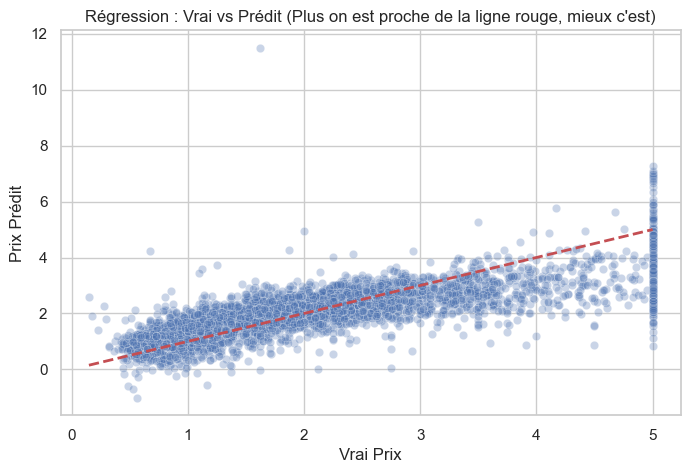

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Création et Entraînement
model_reg = LinearRegression()
model_reg.fit(X_train_scaled, y_train)

# 2. Prédiction (Sur le Test Set)
y_pred_reg = model_reg.predict(X_test_scaled)

# 3. Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)

print(f" R² (Score de précision, max=1) : {r2:.4f}")
print(f" Erreur moyenne (RMSE) : {rmse:.4f} (en centaines de milliers de $)")

# Visualisation : Réalité vs Prédiction
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_reg, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Ligne parfaite
plt.xlabel("Vrai Prix")
plt.ylabel("Prix Prédit")
plt.title("Régression : Vrai vs Prédit (Plus on est proche de la ligne rouge, mieux c'est)")
plt.show()

Le modele a une variance de 58 pourcent entre les donnees 
si r au carre est proche de 0 --> faible relation entre les  valeurs
si r au carre est proche de 1 --> les valeurs sont etroitement liee
*RMSE* = 0.74 donc en moyenne le modele fait une erreur de 75 000 dollars


# Classification (Oui/Non)

On change le problème. On ne veut plus le prix, on veut savoir : **"Est-ce un bien de Luxe ?"**
On va utiliser la **Régression Logistique**.

**Piège classique :** Malgré son nom, c'est un algo de **Classification** ! Elle calcule une probabilité (entre 0% et 100%) d'appartenir à une classe.

## Classification

la matrice de confusion --> pb de classification 


ℹ Seuil de prix pour être 'Luxe' : 1.80
 Précision globale (Accuracy) : 82.63%


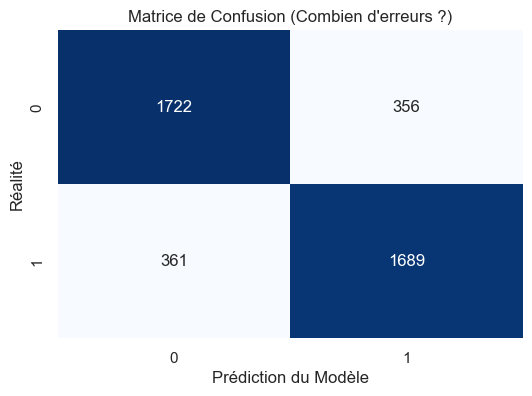

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Feature Engineering : On crée nos classes
# Si Prix > Prix Médian alors CLASSE 1 (Luxe), sinon CLASSE 0 (Standard)
median_price = y_train.median()
y_train_class = (y_train > median_price).astype(int)
y_test_class = (y_test > median_price).astype(int)

print(f"ℹ Seuil de prix pour être 'Luxe' : {median_price:.2f}")

# 2. Entraînement
model_class = LogisticRegression()
model_class.fit(X_train_scaled, y_train_class)

# 3. Prédiction
y_pred_class = model_class.predict(X_test_scaled)

# 4. Évaluation
accuracy = accuracy_score(y_test_class, y_pred_class)
conf_matrix = confusion_matrix(y_test_class, y_pred_class)

print(f" Précision globale (Accuracy) : {accuracy:.2%}")

# Visualisation de la Matrice de Confusion
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Prédiction du Modèle')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion (Combien d\'erreurs ?)')
plt.show()

#  Étape 4 : Clustering (Non Supervisé)

Ici, on oublie le PRIX. On cache la réponse.
On demande à l'algorithme : *"Regarde les données et fais-moi des groupes de maisons qui se ressemblent"*.

**Algorithme :** K-Means.
On va chercher **3 profils types** de quartiers californiens.

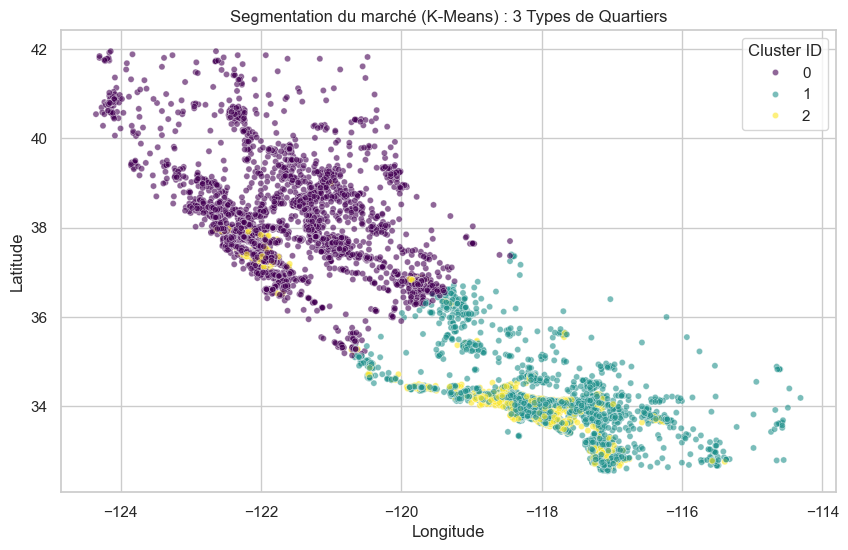

👀 Observez la carte : L'IA a redessiné la carte de la Californie (Nord/Sud/Zones riches) sans savoir où sont les villes !


In [9]:
from sklearn.cluster import KMeans

# 1. Préparation : On garde Latitude, Longitude et Revenu pour voir des zones géo
X_cluster = X_train_scaled[['Latitude', 'Longitude', 'Revenu_Moyen']]

# 2. K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_cluster)
clusters = kmeans.labels_

# 3. Visualisation Géographique
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['Longitude'], y=X_train['Latitude'], hue=clusters, palette='viridis', s=20, alpha=0.6)
plt.title('Segmentation du marché (K-Means) : 3 Types de Quartiers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster ID')
plt.show()

print("👀 Observez la carte : L'IA a redessiné la carte de la Californie (Nord/Sud/Zones riches) sans savoir où sont les villes !")

#  Étape 5 : Le Deep Learning (Réseau de Neurones)

C'est le moment de sortir l'artillerie lourde.
Au lieu d'une formule simple, on va construire un **Cerveau Artificiel** avec `Keras` (TensorFlow).

* **Couches Dense :** Des neurones connectés entre eux.
* **Activation ReLU :** Pour comprendre les relations non-linéaires (complexes).
* **Époques :** Le nombre de fois où le modèle révise tout le cours.

c:\Users\kylli\anaconda3\envs\NETFLIX_DATA\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Entraînement du réseau de neurones en cours...
 Entraînement terminé !


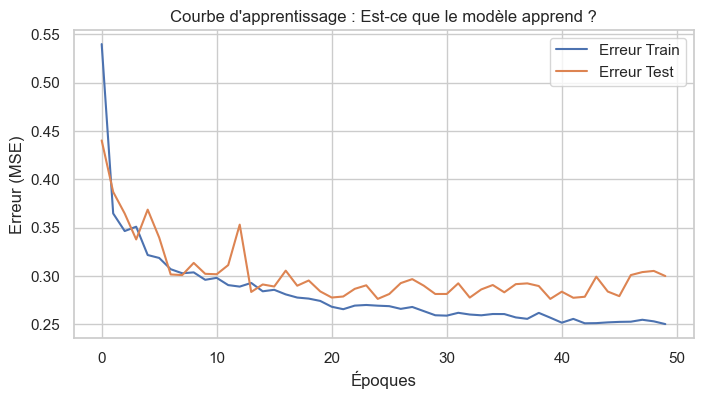

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step

 MATCH FINAL :
Régression Linéaire Classique (R²) : 0.5758
Deep Learning (R²)               : 0.7712

 Vainqueur : DEEP LEARNING (Il a capté les nuances complexes)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Architecture du Réseau (Le Cerveau)
model_dl = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Entrée + Couche cachée 1
    Dense(32, activation='relu'), # Couche cachée 2
    Dense(1) # Sortie (Un seul chiffre : Le Prix)
])

# 2. Compilation
model_dl.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# 3. Entraînement (Ça tourne !)
print(" Entraînement du réseau de neurones en cours...")
history = model_dl.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,       # 50 cycles de révision
    batch_size=32,   # Par paquets de 32 maisons
    verbose=0        # On cache le blabla technique
)
print(" Entraînement terminé !")

# 4. Courbe d'apprentissage (Loss)
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Erreur Train')
plt.plot(history.history['val_loss'], label='Erreur Test')
plt.title('Courbe d\'apprentissage : Est-ce que le modèle apprend ?')
plt.ylabel('Erreur (MSE)')
plt.xlabel('Époques')
plt.legend()
plt.show()

# 5. Comparaison Finale
y_pred_dl = model_dl.predict(X_test_scaled)
r2_dl = r2_score(y_test, y_pred_dl)

print(f"\n MATCH FINAL :")
print(f"Régression Linéaire Classique (R²) : {r2:.4f}")
print(f"Deep Learning (R²)               : {r2_dl:.4f}")

if r2_dl > r2:
    print("\n Vainqueur : DEEP LEARNING (Il a capté les nuances complexes)")
else:
    print("\n Vainqueur : MACHINE LEARNING CLASSIQUE (Parfois, faire simple suffit !)")

#  Conclusion : L'Akram-pendium

Bravo, vous avez survécu.

###  Avertissement
Ce notebook est une introduction. L'univers de la Data est infini.
Prochaines étapes pour votre carrière : **Random Forest, XGBoost, CNN (Images), Transformers (ChatGPT)...**

###  La méthode B.I.B.L.E (Selon Akram)
Pour ne jamais échouer un projet, souvenez-vous de ceci :

* **B**ase de données (Vérifie toujours la qualité avant de coder)
* **I**ntelligence (Comprends le métier avant l'algorithme)
* **B**idon (Ce que sera ton modèle si tu ne nettoies pas la donnée)
* **L**ogique (Choisis le bon outil : ne prends pas un bazooka Deep Learning pour tuer une mouche)
* **E**xpertise... **Celle d'Akram, bien sûr ! 😉**

*Gardez ce fichier précieusement. Dupliquez-le. Utilisez-le.*

: 

: 